In [461]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import seaborn as sns
import matplotlib.pyplot as plt

In [462]:
# Загрузка данных
data = pd.read_csv('data/etalon_df.csv', index_col=0)
# data = pd.read_csv('data/pat_etalon_df.csv')
data.drop(columns='study_ID', inplace=True)
# data.drop(columns='ID истории болезни', inplace=True)
data

,gender,age,rbc,hgb,hct,mcv,mchc,rdw,rdv_sd,ret_abs,...,pdw,plcr,soe,myelo,yunye,blasty,normoblast,normobl_abs,prolym,promyelo
0,0,87,2.21000,84.000000,26.300000,119.100000,320.00000,21.300000,52.144544,36.245919,...,16.438954,0.0,12.000000,1.0,2.0,0.0,0.0,0.0,0.0,0.0
1,0,87,1.91000,74.000000,23.600000,123.800000,315.00000,12.280473,41.106126,33.459317,...,16.905172,0.0,3.174857,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0,87,4.54908,132.748598,44.744731,81.555698,336.94953,20.500000,43.022613,44.313909,...,15.528221,0.0,3.486072,1.0,1.0,0.0,0.0,0.0,0.0,0.0
3,0,87,2.97000,107.000000,32.500000,109.400000,329.00000,22.200000,38.790873,43.477298,...,15.175393,0.0,16.000000,0.0,2.0,0.0,0.0,0.0,0.0,0.0
5,1,51,7.29000,146.000000,48.500000,66.500000,301.00000,13.692463,40.780142,24.427060,...,15.951140,0.0,4.625649,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3110,1,71,3.15000,88.000000,26.000000,83.000000,338.00000,11.984088,57.000000,38.423377,...,15.138585,0.0,3.110324,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3111,1,71,3.17000,94.000000,26.000000,81.000000,366.00000,11.750663,54.000000,28.051271,...,16.490303,0.0,7.517509,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3112,1,71,3.81000,108.000000,31.000000,81.000000,350.00000,11.557387,54.000000,38.610999,...,15.675992,0.0,5.832216,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3113,1,71,4.04000,113.000000,33.000000,81.000000,346.00000,11.997245,54.000000,37.951416,...,15.702718,0.0,4.414060,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [463]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1924 entries, 0 to 3114
Data columns (total 38 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   gender        1924 non-null   int64  
 1   age           1924 non-null   int64  
 2   rbc           1924 non-null   float64
 3   hgb           1924 non-null   float64
 4   hct           1924 non-null   float64
 5   mcv           1924 non-null   float64
 6   mchc          1924 non-null   float64
 7   rdw           1924 non-null   float64
 8   rdv_sd        1924 non-null   float64
 9   ret_abs       1924 non-null   float64
 10  cp            1924 non-null   float64
 11  anisocytos    1924 non-null   float64
 12  hypochromia   1924 non-null   float64
 13  macrocytos    1924 non-null   float64
 14  microcytos    1924 non-null   float64
 15  poikilocytos  1924 non-null   float64
 16  wbc           1924 non-null   float64
 17  ne_abs        1924 non-null   float64
 18  ly_abs        1924 non-null   flo

In [464]:

def check_data_quality(data,
                       freq_treshold=0.95,
                       nunique_threshold=0.95,
                       null_threshold=0):
    """Проводит поиск дублей, пропусков и неинформативных признаков и выводит результат в консоль.
    
    Неинформативным считается признак с долей уникальных значений или повторов выше установленного порога.
    
    Parameters
    ----------
        data : DataFrame
            Датафрейм для анализа
        freq_treshold : float
            Порог масимальной частоты встречаемости признака
        nunique_treshhold : float
            Порог максимальной уникальности признака
        null_threshold : float
            Порог максимального отстутсвия признака
    """
    
    # Поиск дублей
    try:
        print(f'Число найденных дублей: {
            data.duplicated().value_counts().loc[True]
            }\n')
    except KeyError:
        print('Количество дублей: 0\n')

    # Поиск пропущенных значений
    cols_null_percent = data.isnull().mean()
    cols_with_null = cols_null_percent[cols_null_percent > null_threshold]\
        .sort_values(ascending=False)
    if cols_with_null.shape[0]: display(cols_with_null)
    print(f'Количество признаков с пустыми значениями: {cols_with_null.shape[0]}\n')

    # Поиск неинформативных признаков
    low_information_cols = []
    bad_feat_flag = False
    # цикл по всем столбцам
    for col in data.columns:
        #наибольшая относительная частота в признаке
        top_freq = data[col].value_counts(normalize=True).max()
        #доля уникальных значений от размера признака
        nunique_ratio = data[col].nunique() / data[col].count()
        # сравниваем наибольшую частоту с порогом
        if top_freq > freq_treshold:
            bad_feat_flag = True
            low_information_cols.append(col)
            print(f'{col}: {top_freq:.2%} одинаковых значений')
        # сравниваем долю уникальных значений с порогом
        if nunique_ratio > nunique_threshold:
            bad_feat_flag = True
            low_information_cols.append(col)
            print(f'{col}: {nunique_ratio:.2%} уникальных значений')
    if not bad_feat_flag:
        print('Неинформативных признаков не найдено.')

In [465]:
cat_list = ['gender', 'plasma', 'myelo', 'yunye', 'blasty',
            'prolym', 'promyelo', 'normoblast', 'hypochromia',
            'macrocytos', 'microcytos', 'anisocytos', 'poikilocytos',]
num_list = [col for col in data.columns if col not in cat_list]
data[cat_list] = data[cat_list].astype('object')

In [466]:
print('Проверка тренировочной выборки:'+'\n'+'-' * 30)
check_data_quality(data)

Проверка тренировочной выборки:
------------------------------
Количество дублей: 0

Количество признаков с пустыми значениями: 0

ret_abs: 100.00% уникальных значений
hypochromia: 98.49% одинаковых значений
macrocytos: 99.43% одинаковых значений
microcytos: 99.17% одинаковых значений
poikilocytos: 95.11% одинаковых значений
plasma: 98.96% одинаковых значений
plcr: 95.84% одинаковых значений
normoblast: 99.74% одинаковых значений
prolym: 99.84% одинаковых значений
promyelo: 99.95% одинаковых значений


In [467]:
# data.drop(columns=[
#     'ret_abs',
#     # 'hypochromia', 'macrocytos', 'microcytos',
#     # 'poikilocytos', 'plasma', 'plcr', 'normoblast',
#     # 'prolym', 'promyelo'
# ], inplace=True)

In [468]:
def outliers_iqr(data: pd.DataFrame, feature: str, left: float=1.5, 
                 rigth: float=1.5, log_scale: bool=False) -> tuple:
    """Функция расчитывает выбросы по межквартильному размаху (метод Тьюки)
    и возвращает кортеж с двумя датафреймами - чистый и с выбросами"""
    if log_scale:
        x = np.log(data[feature])
    else:
        x = data[feature]
    quartile_1, quartile_3 = x.quantile(0.25), x.quantile(0.75),
    iqr = quartile_3 - quartile_1
    lower_bound = quartile_1 - (iqr * left)
    upper_bound = quartile_3 + (iqr * rigth)
    outliers = data[(x < lower_bound) | (x > upper_bound)]
    cleaned = data[(x >= lower_bound) & (x <= upper_bound)]
    return outliers, cleaned

def outliers_z_score(data: pd.DataFrame, feature: str, left: float=3, 
                     right: float=3, log_scale: bool=False) -> tuple:
    """Функция расчитывает выбросы методом сигм (Z - отклонений)
    и возвращает кортеж с двумя датафреймами - чистый и с выбросами"""
    if log_scale:
        x = np.log(data[feature])
    else:
        x = data[feature]
    mu = x.mean()
    sigma = x.std()
    lower_bound = mu - left * sigma
    upper_bound = mu + right * sigma
    outliers = data[(x < lower_bound) | (x > upper_bound)]
    cleaned = data[(x >= lower_bound) & (x <= upper_bound)]
    return outliers, cleaned

/var/folders/qk/1wwv7nb11h91kq3j74pdwfz00000gn/T/ipykernel_16527/2224855337.py:2: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 4))


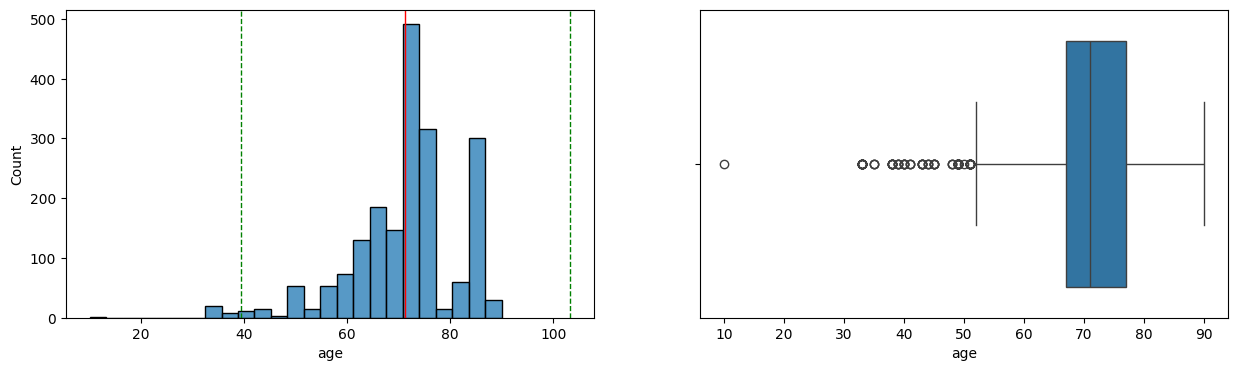

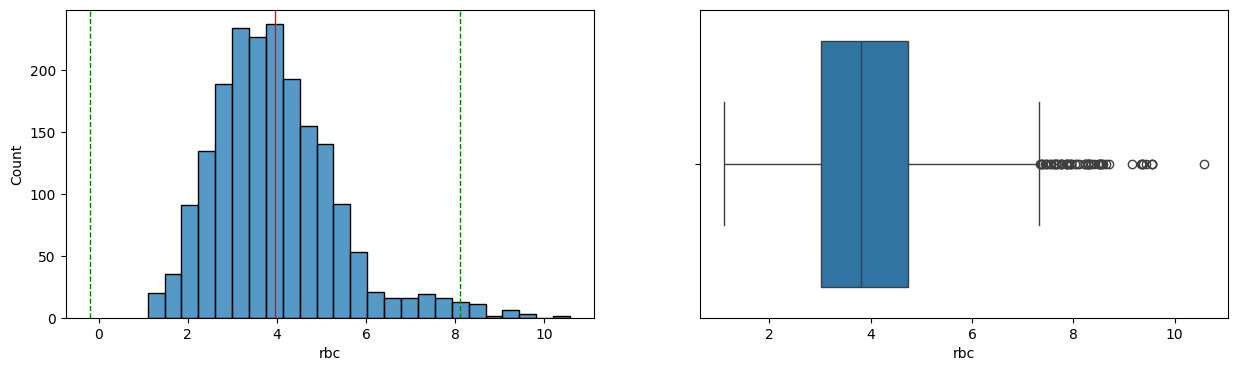

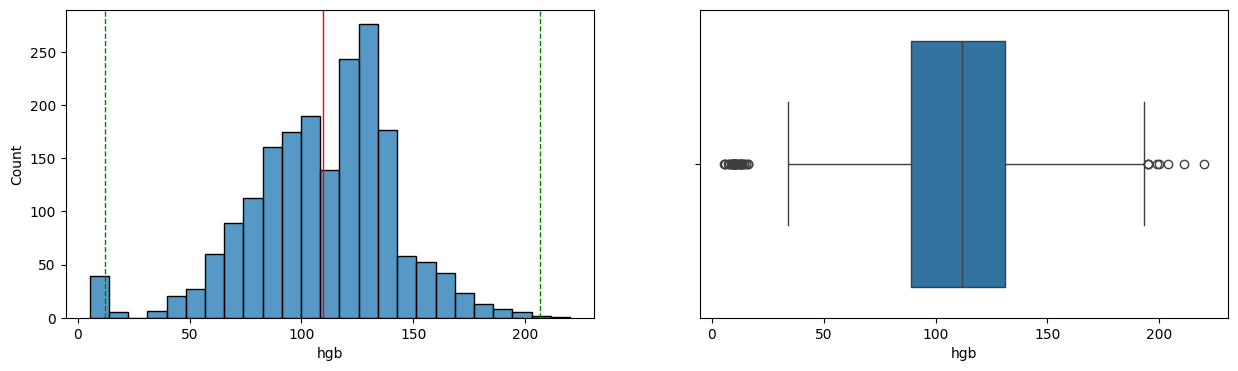

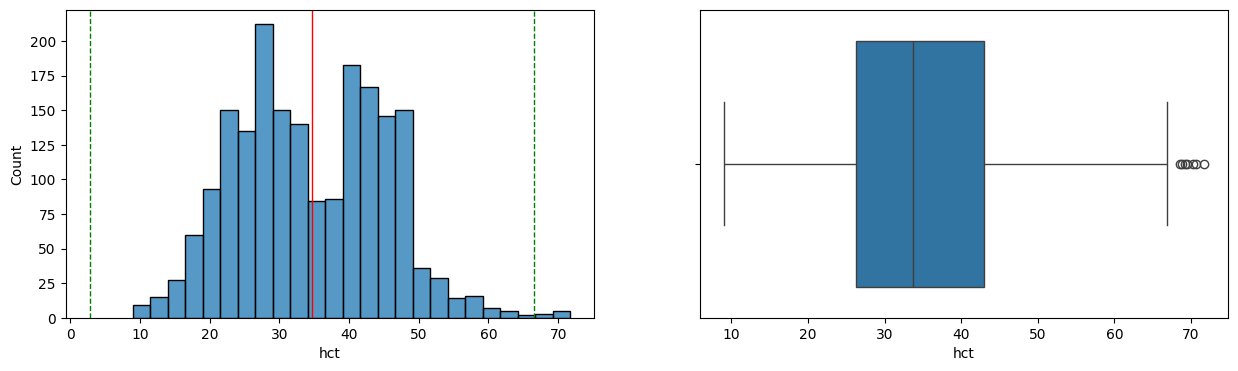

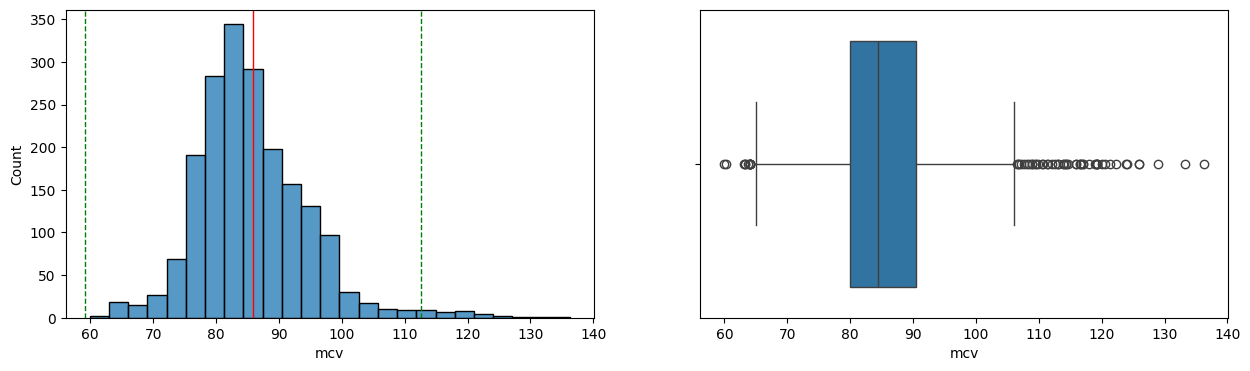

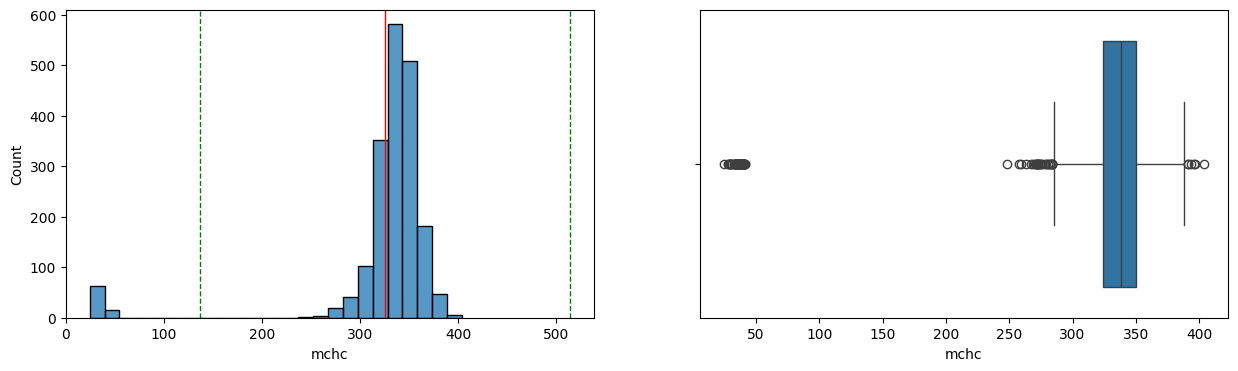

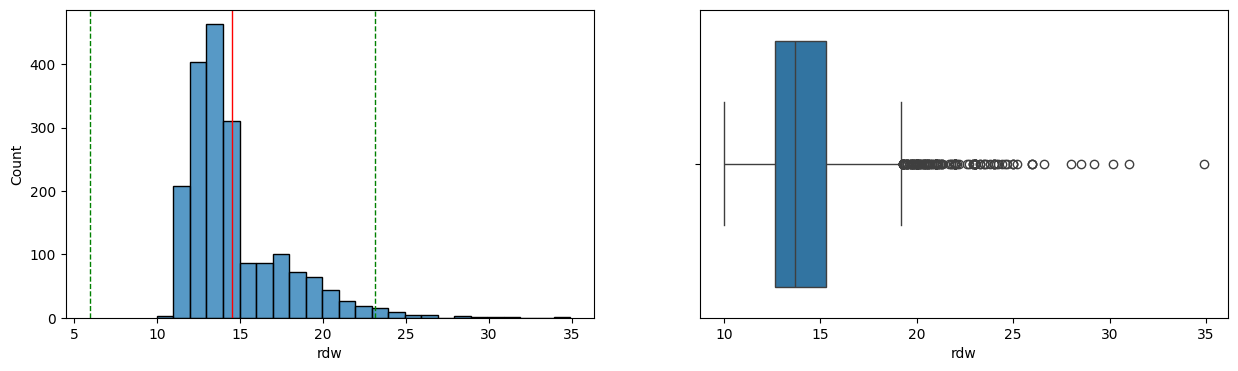

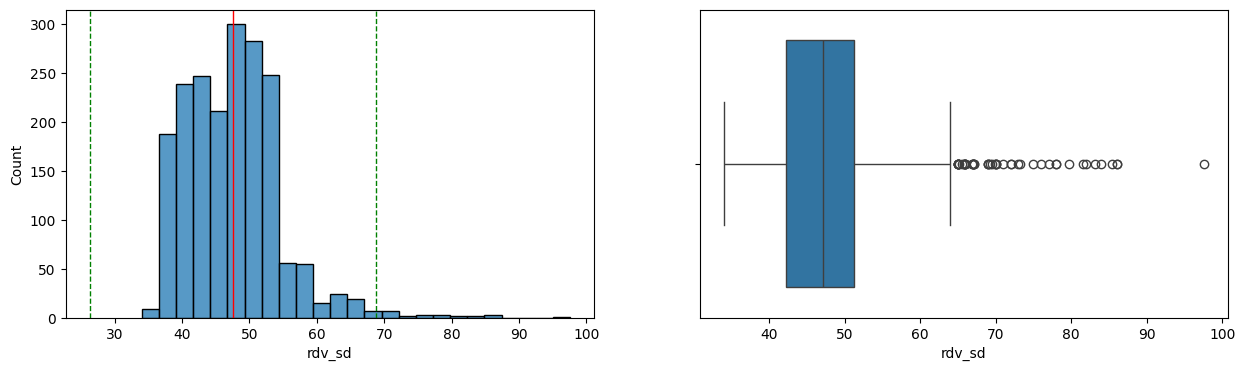

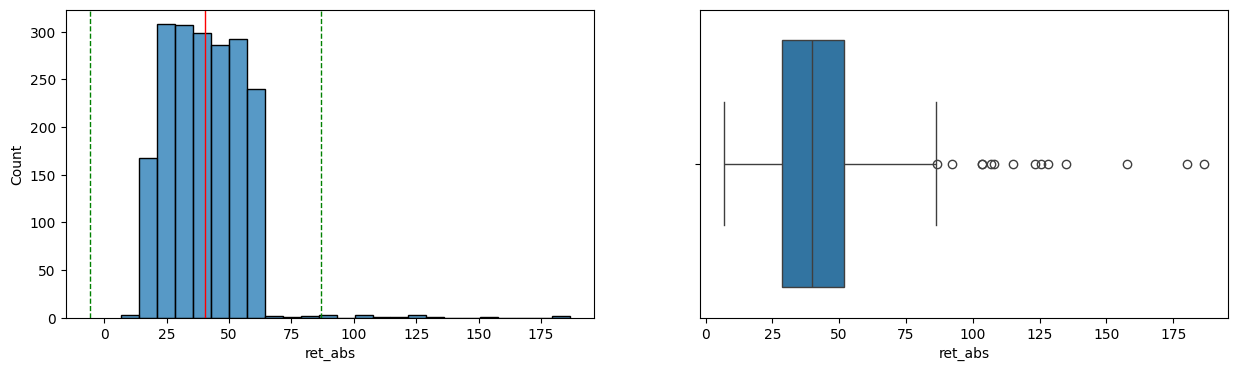

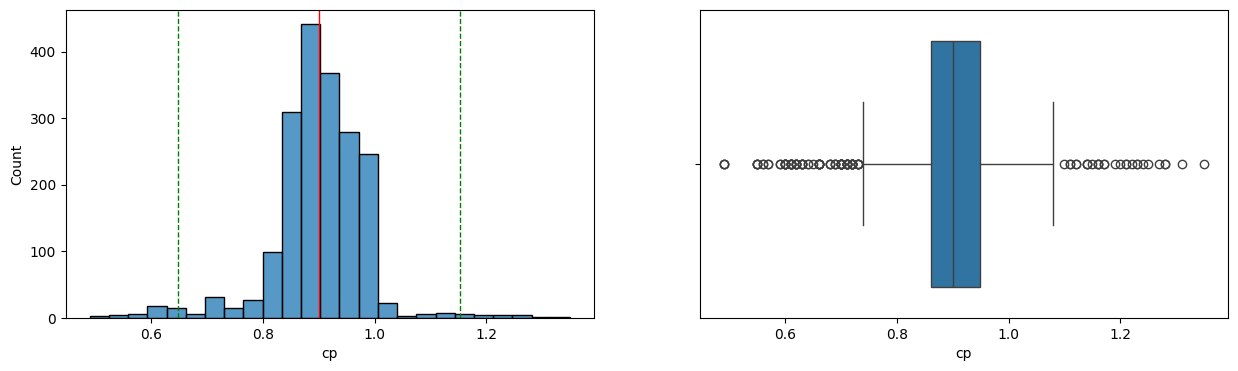

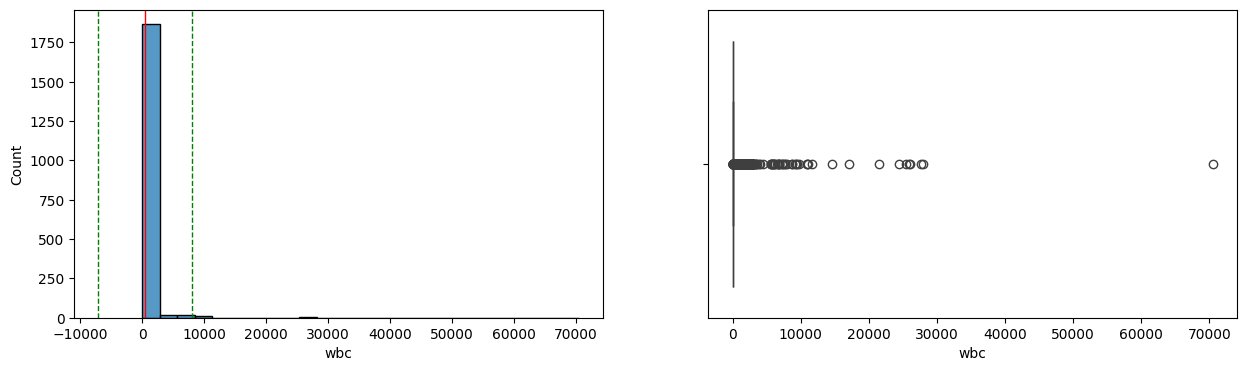

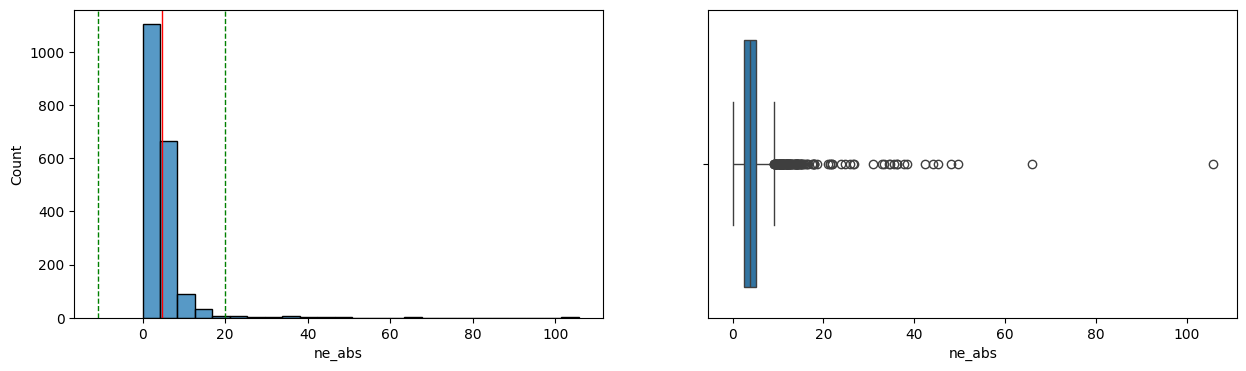

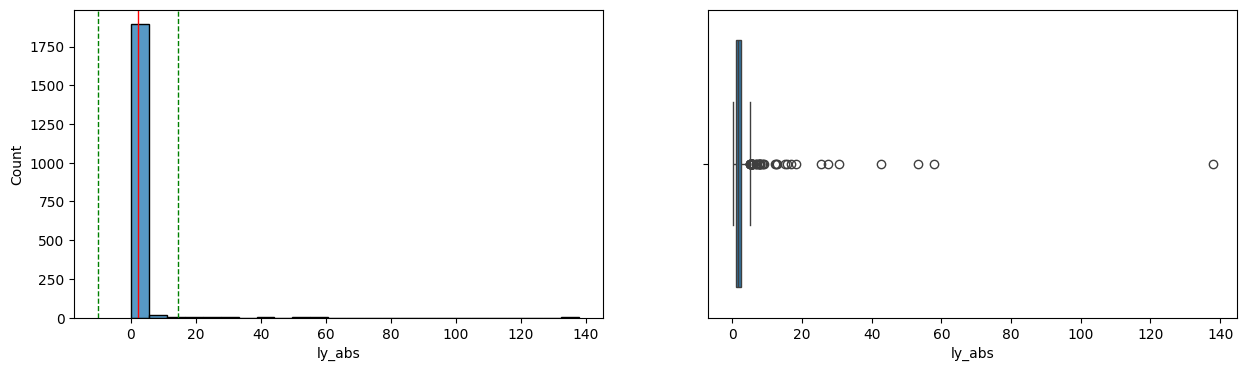

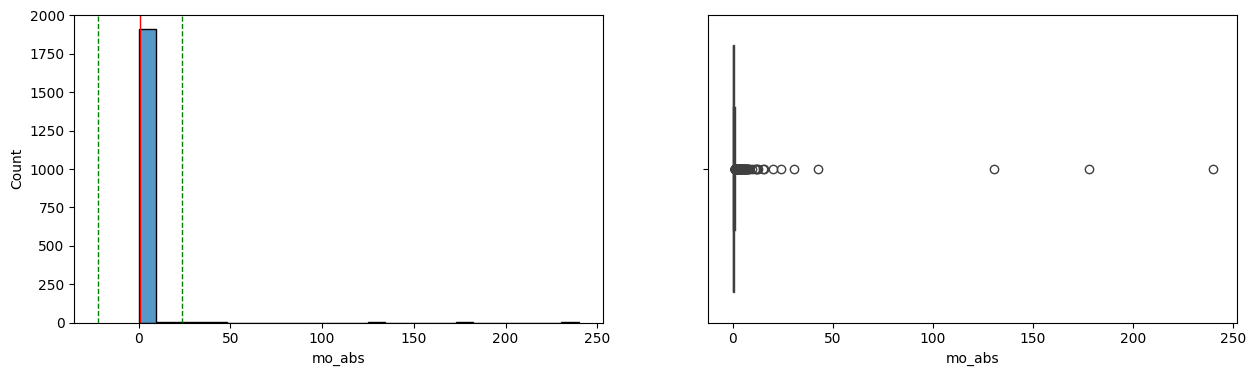

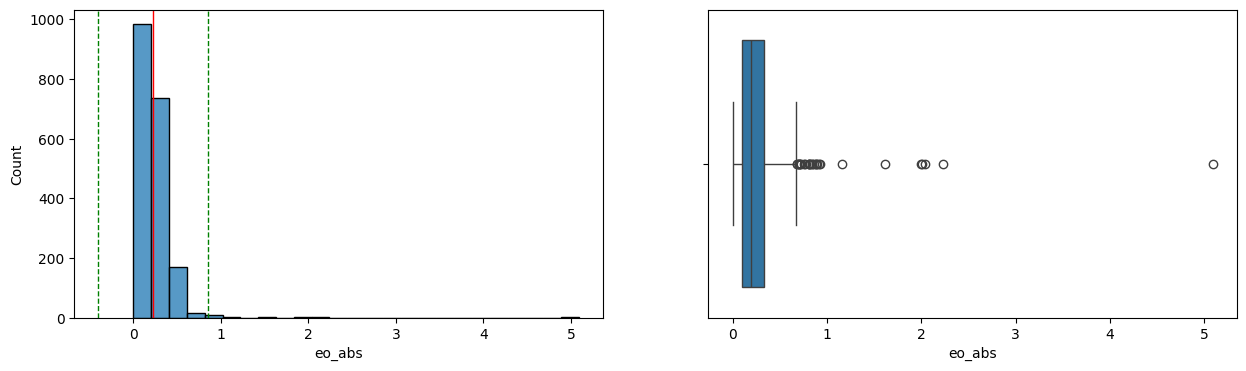

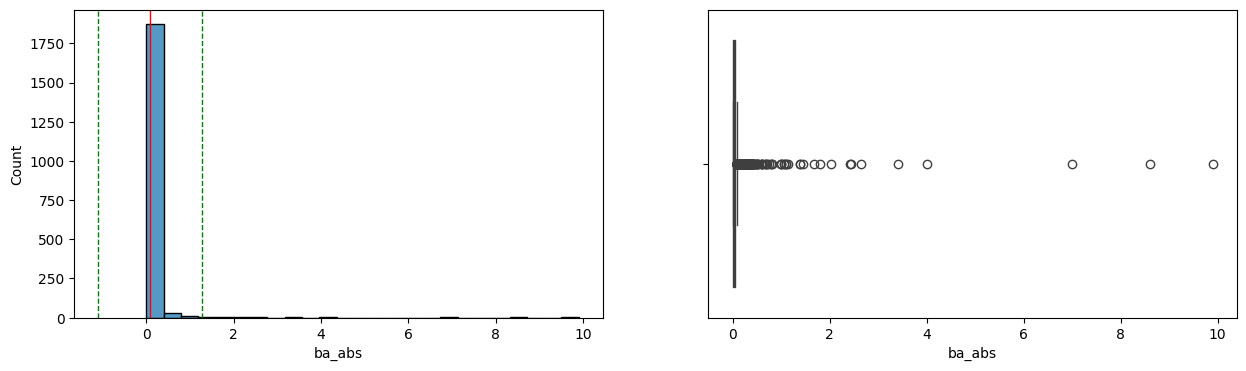

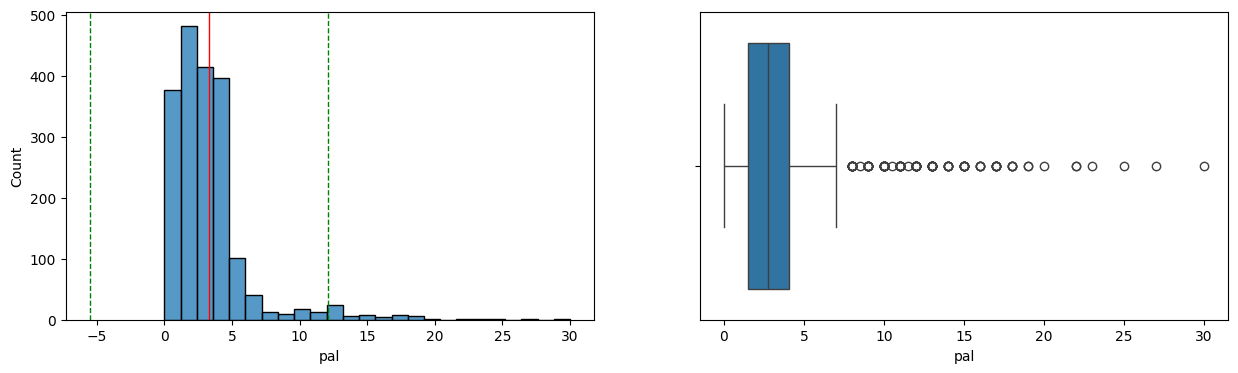

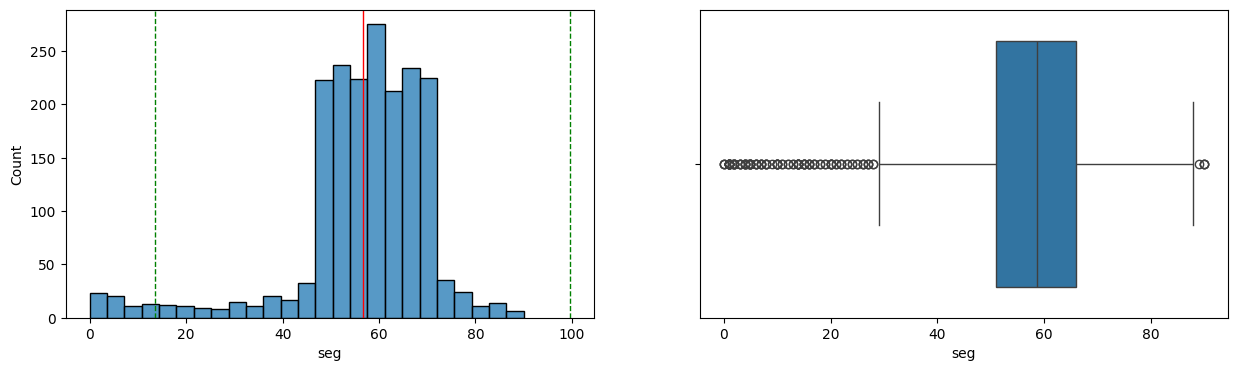

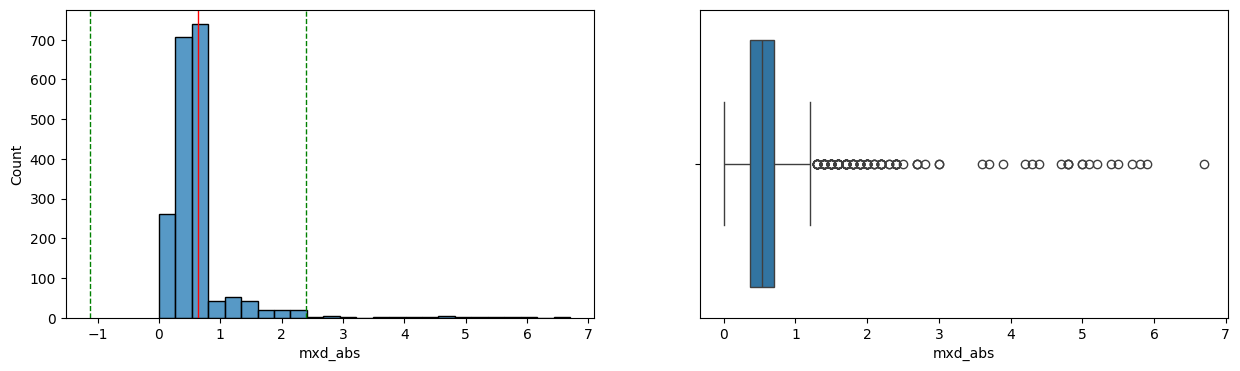

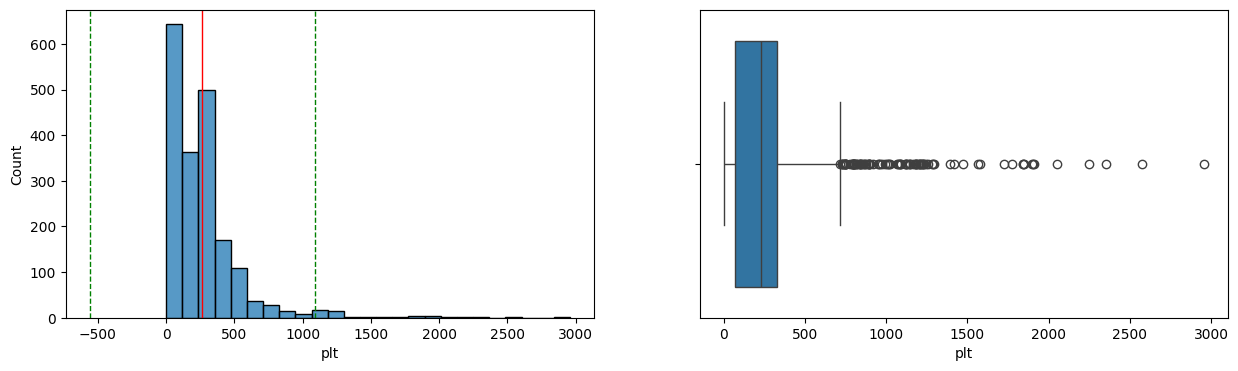

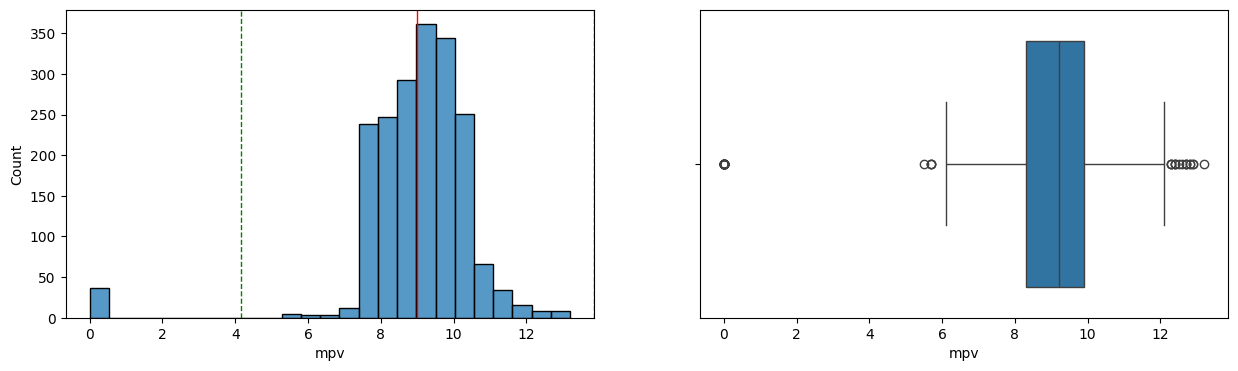

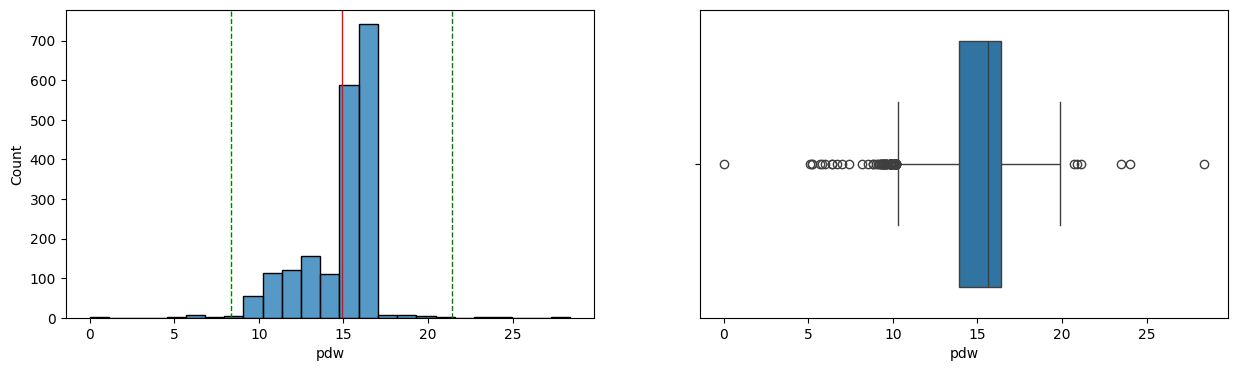

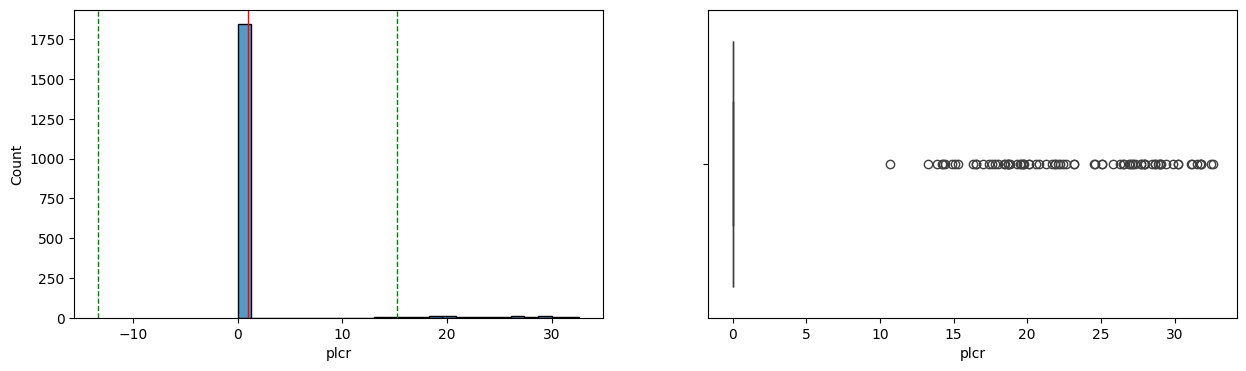

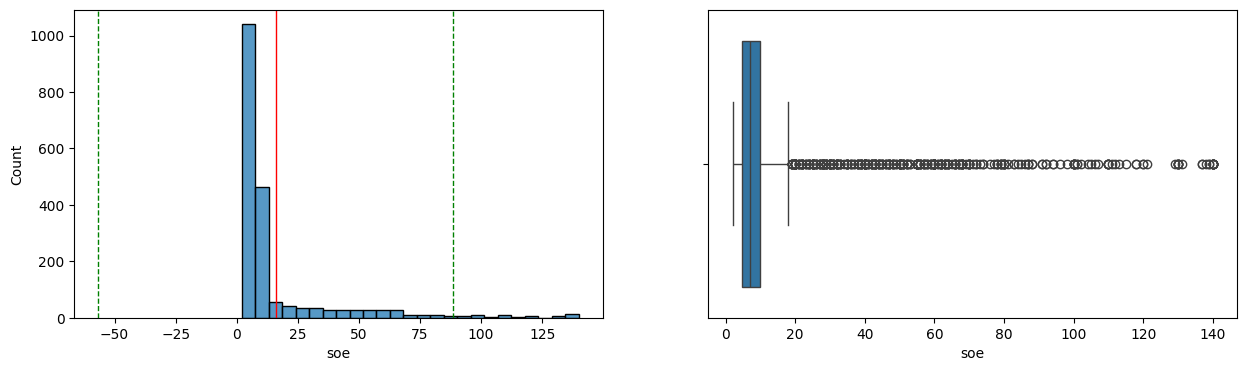

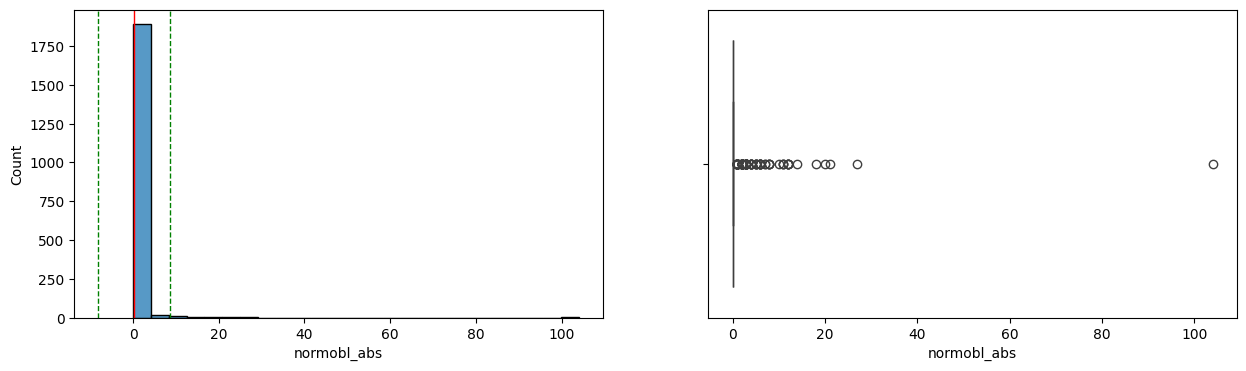

In [469]:
for el in num_list:
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 4))
    histplot = sns.histplot(data=data, x=el, ax=axes[0], bins=25)
    histplot.axvline(data[el].mean(), color='r', lw=1)
    histplot.axvline(data[el].mean()+ 3 * data[el].std(), color='g', ls='--', lw=1)
    histplot.axvline(data[el].mean()- 3 * data[el].std(), color='g', ls='--', lw=1)
    boxplot = sns.boxplot(data=data, x=el, ax=axes[1]);

In [470]:
for el in num_list:
    print(f'\n{'-' * 50}\nВыбросы признака {el}\n' + '-' * 50)
    outliers_irq, cleaned_irq = outliers_iqr(data, el)
    print(f'Число выбросов по методу Тьюки: {outliers_irq.shape[0]}')
    print(f'Результирующее число записей: {cleaned_irq.shape[0]}')
    print()
    outliers_z, cleaned_z = outliers_z_score(data, el)
    print(f'Число выбросов по методу z-отклонения: {outliers_z.shape[0]}')
    print(f'Результирующее число записей: {cleaned_z.shape[0]}')

    data = cleaned_irq


--------------------------------------------------
Выбросы признака age
--------------------------------------------------
Число выбросов по методу Тьюки: 110
Результирующее число записей: 1814

Число выбросов по методу z-отклонения: 32
Результирующее число записей: 1892

--------------------------------------------------
Выбросы признака rbc
--------------------------------------------------
Число выбросов по методу Тьюки: 67
Результирующее число записей: 1747

Число выбросов по методу z-отклонения: 31
Результирующее число записей: 1783

--------------------------------------------------
Выбросы признака hgb
--------------------------------------------------
Число выбросов по методу Тьюки: 44
Результирующее число записей: 1703

Число выбросов по методу z-отклонения: 41
Результирующее число записей: 1706

--------------------------------------------------
Выбросы признака hct
--------------------------------------------------
Число выбросов по методу Тьюки: 0
Результирующее число запи

/var/folders/qk/1wwv7nb11h91kq3j74pdwfz00000gn/T/ipykernel_16527/2224855337.py:2: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 4))


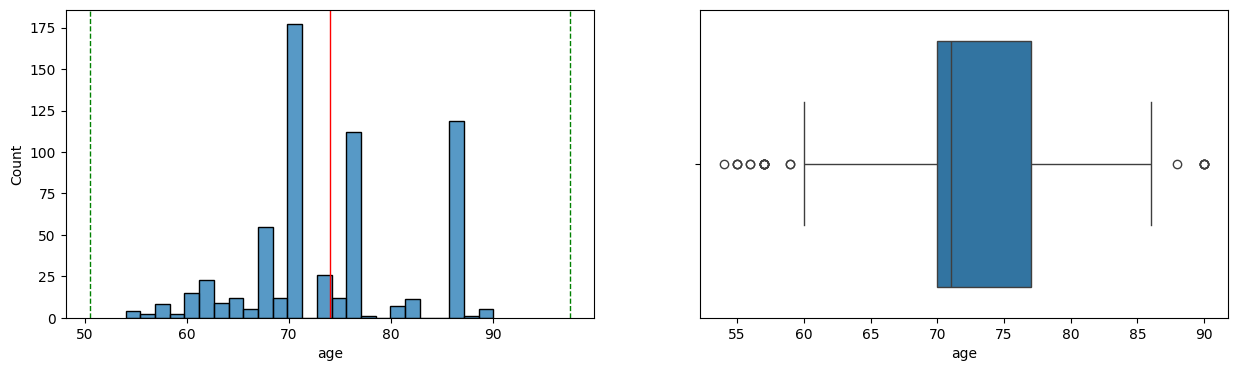

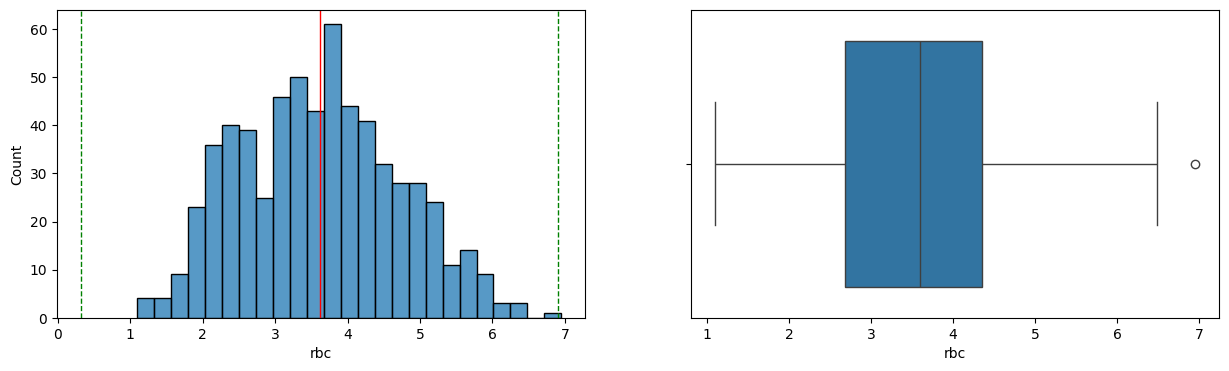

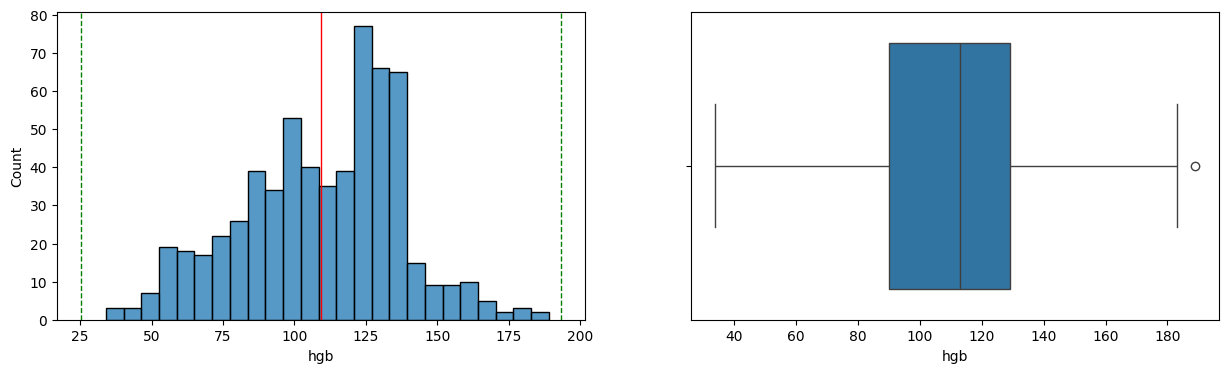

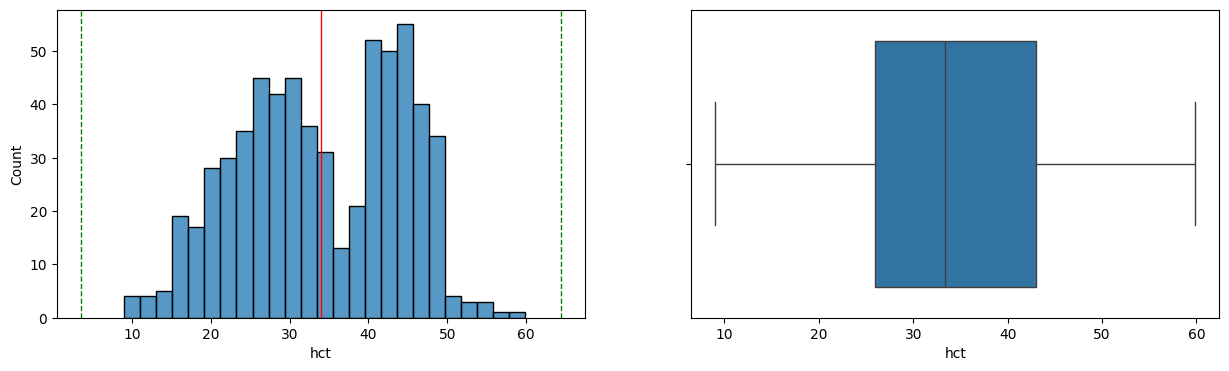

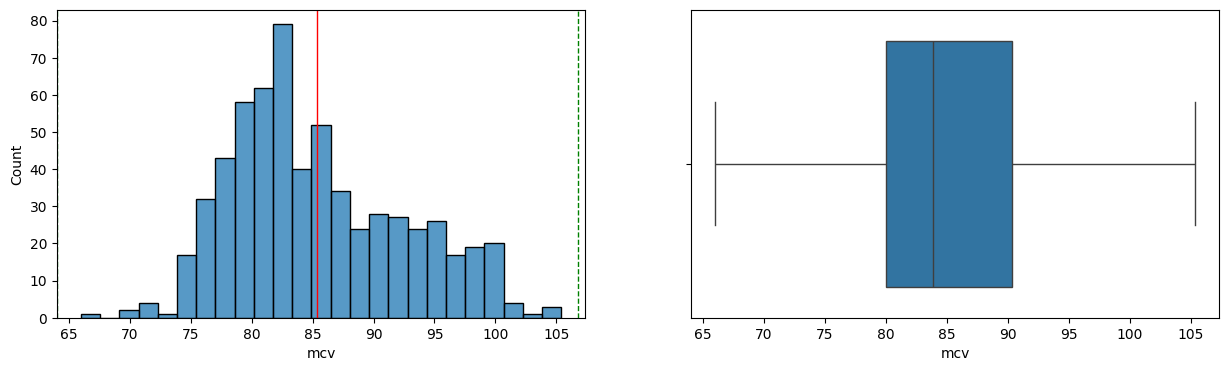

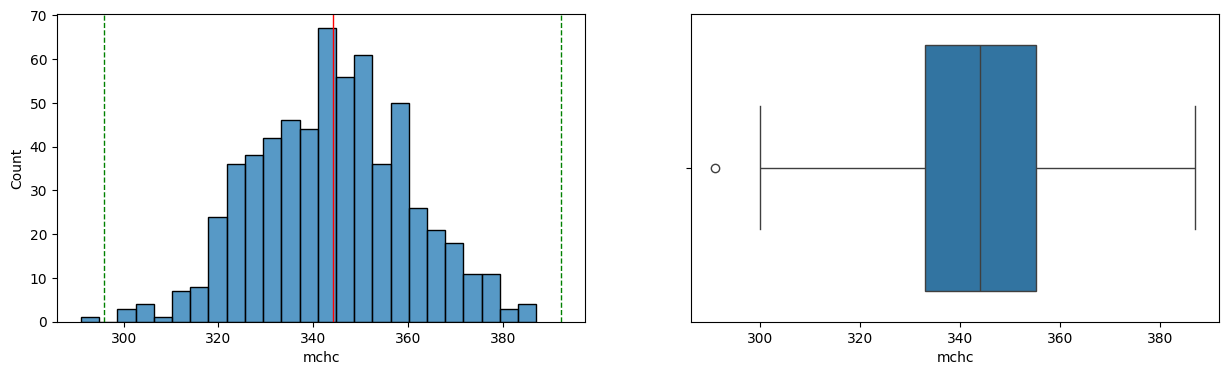

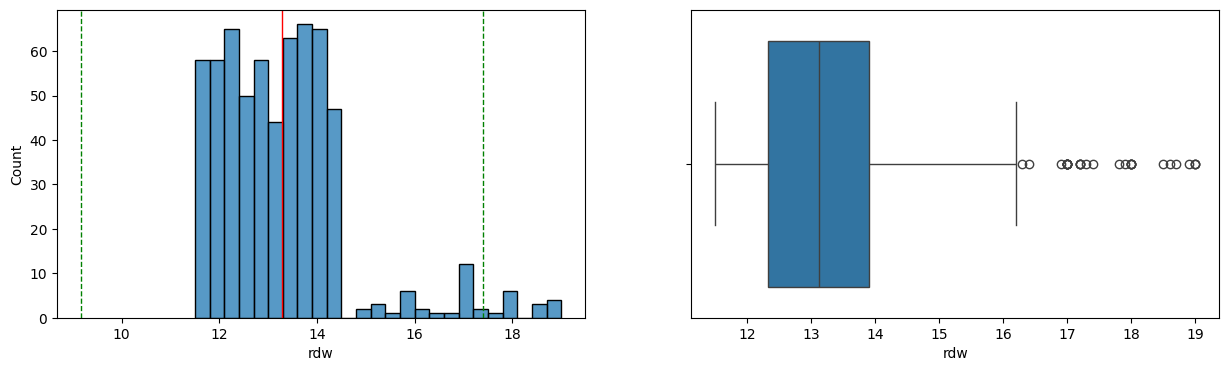

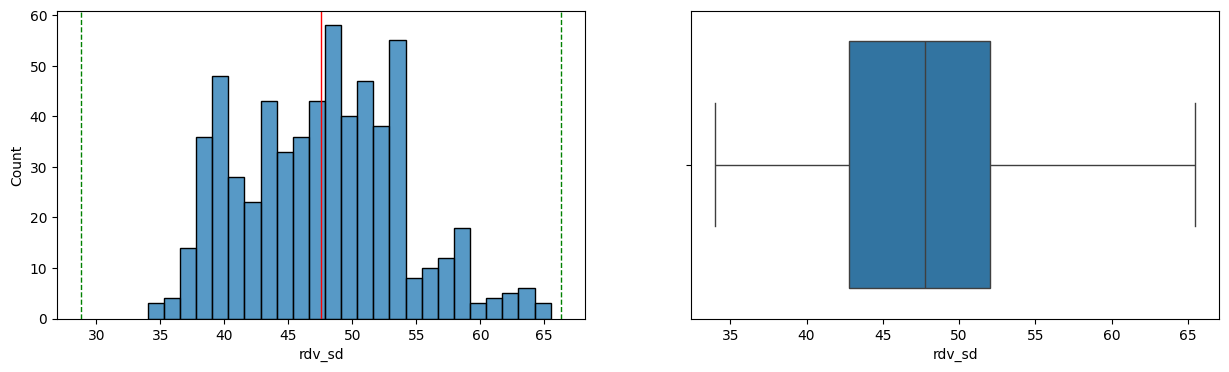

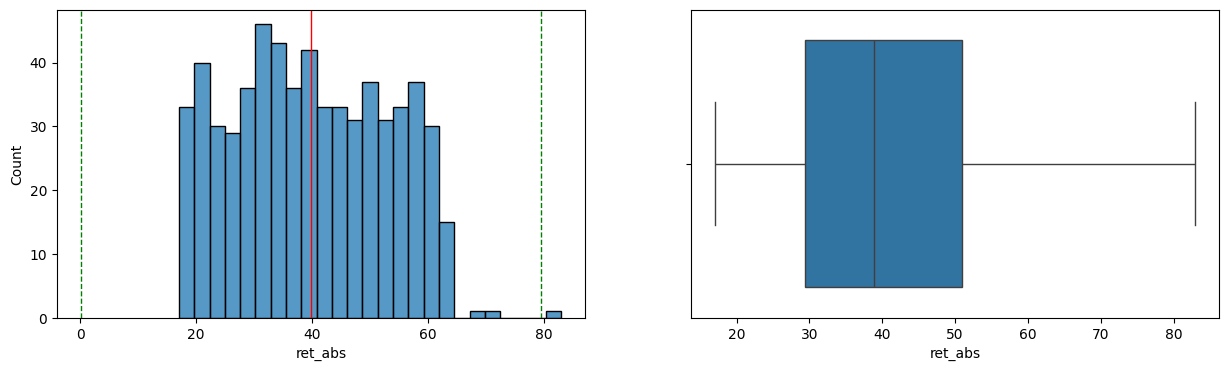

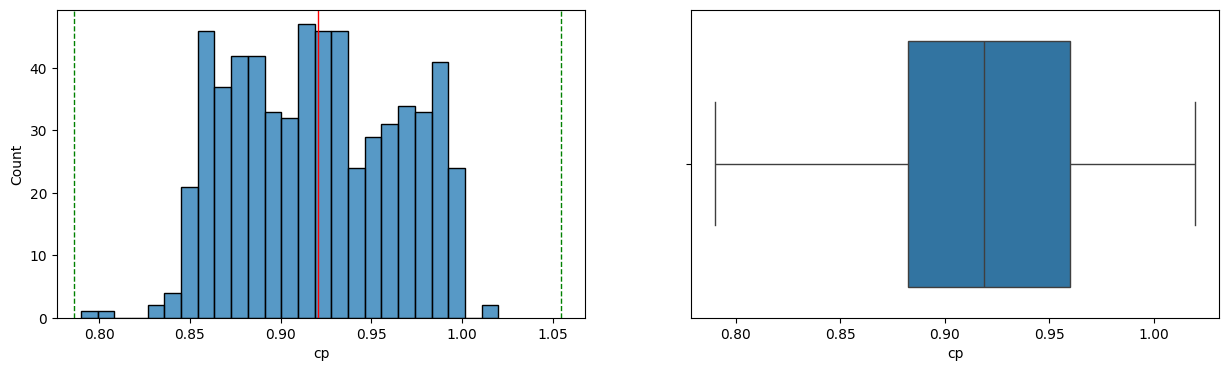

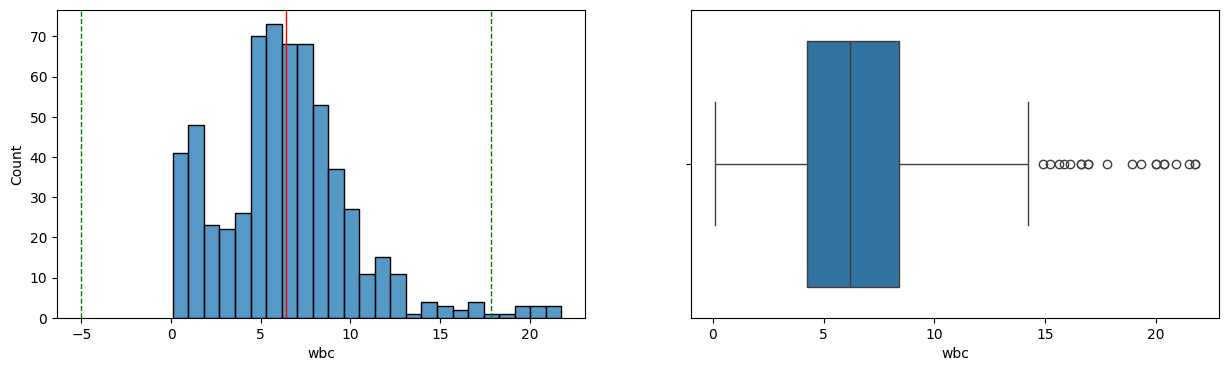

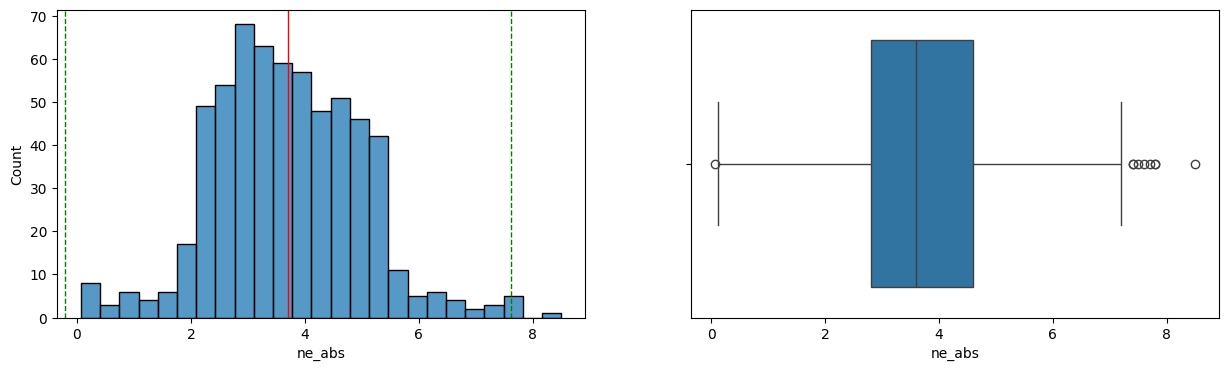

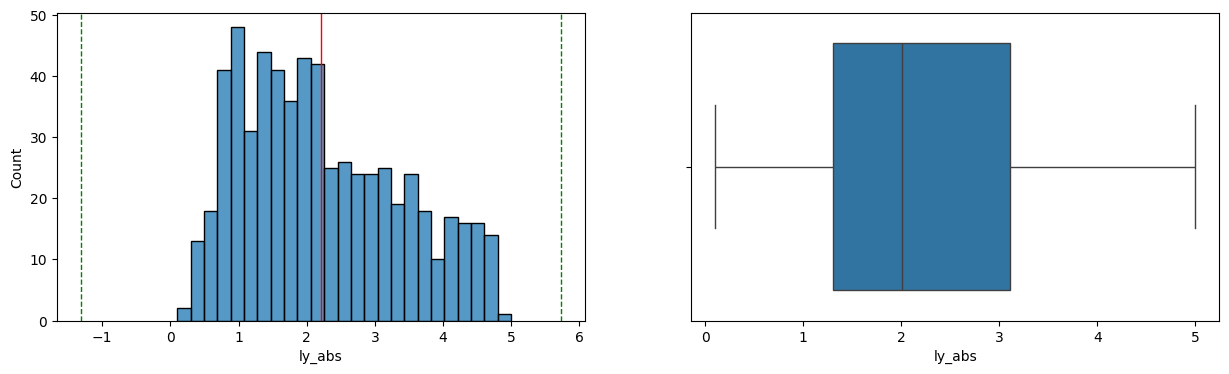

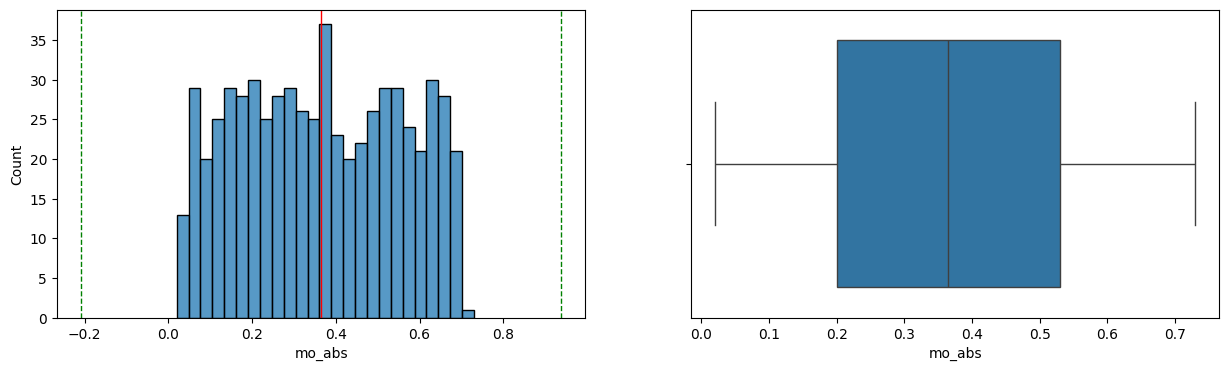

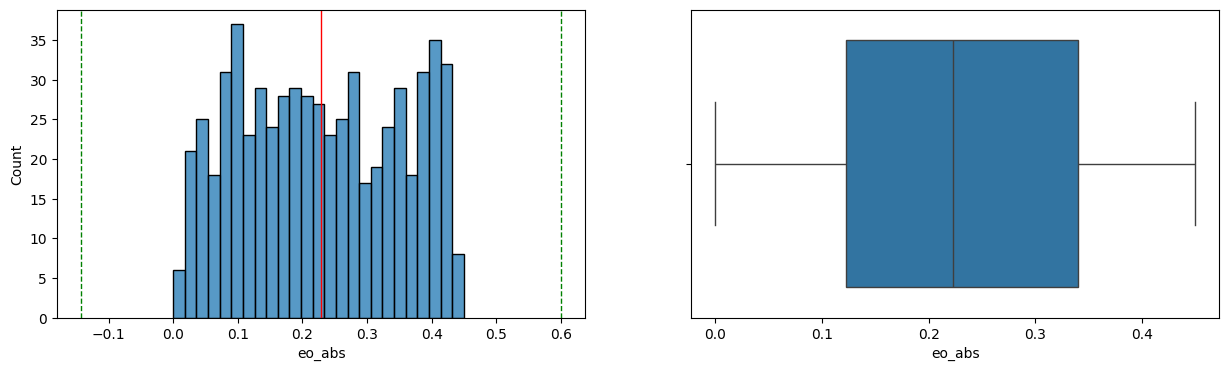

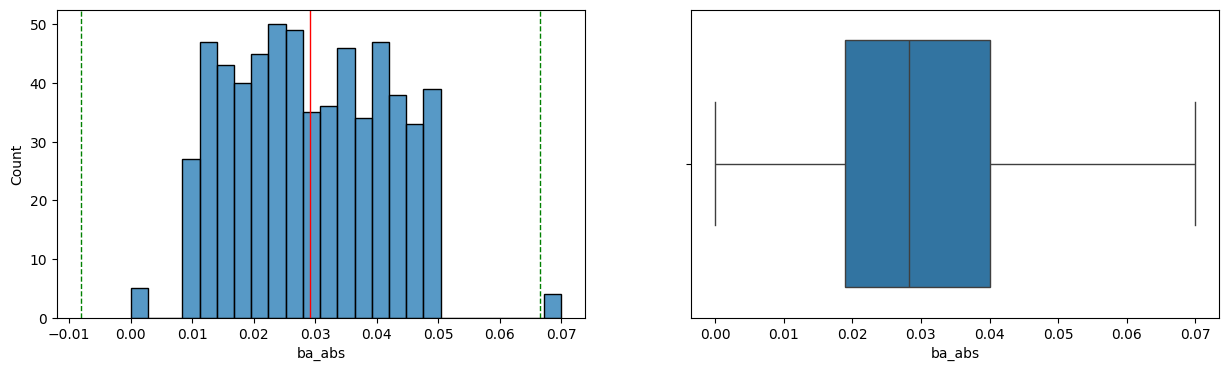

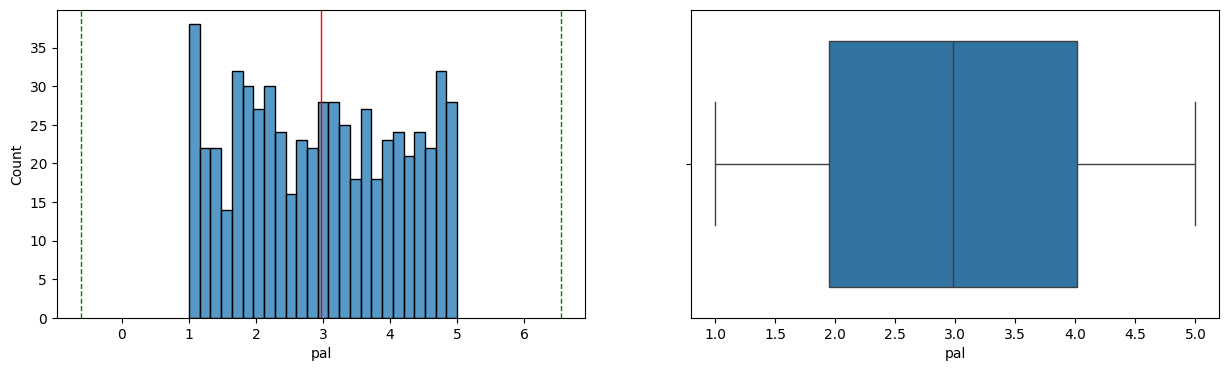

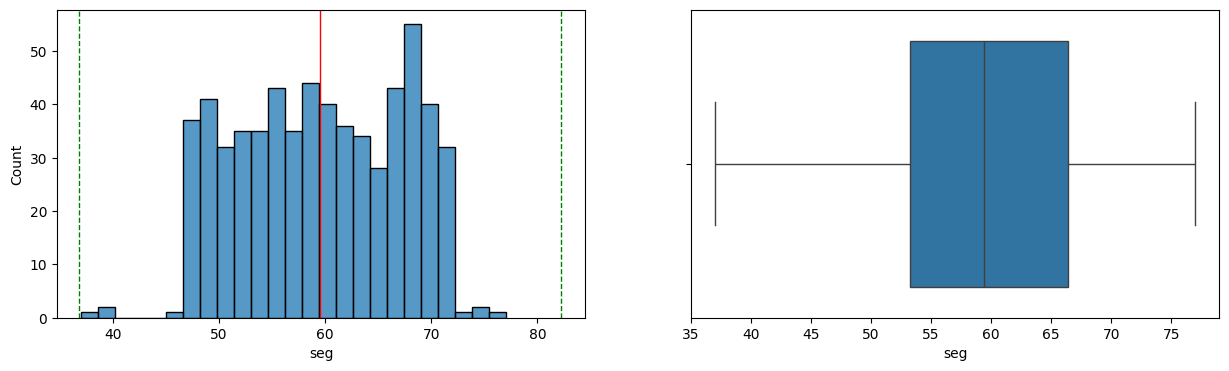

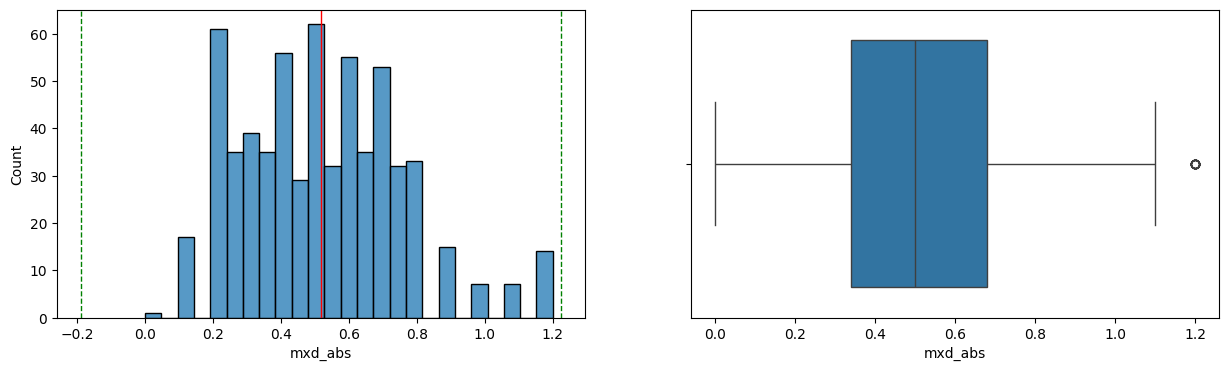

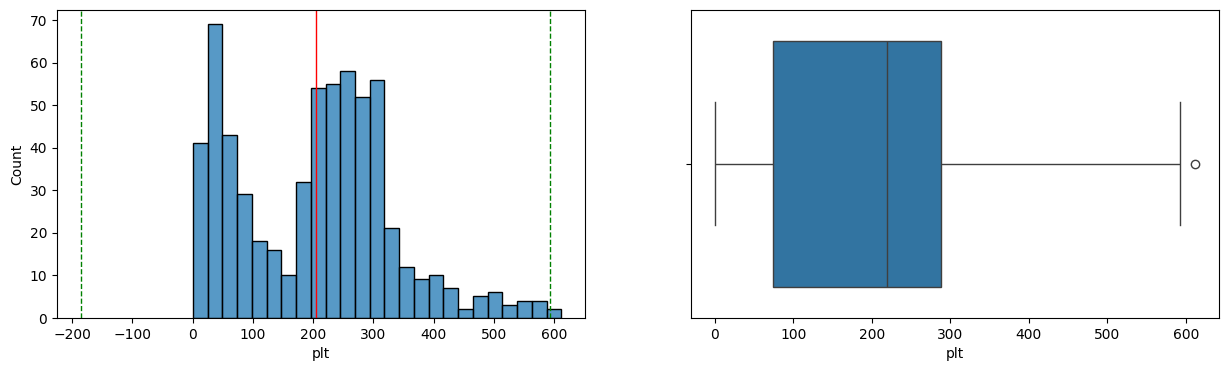

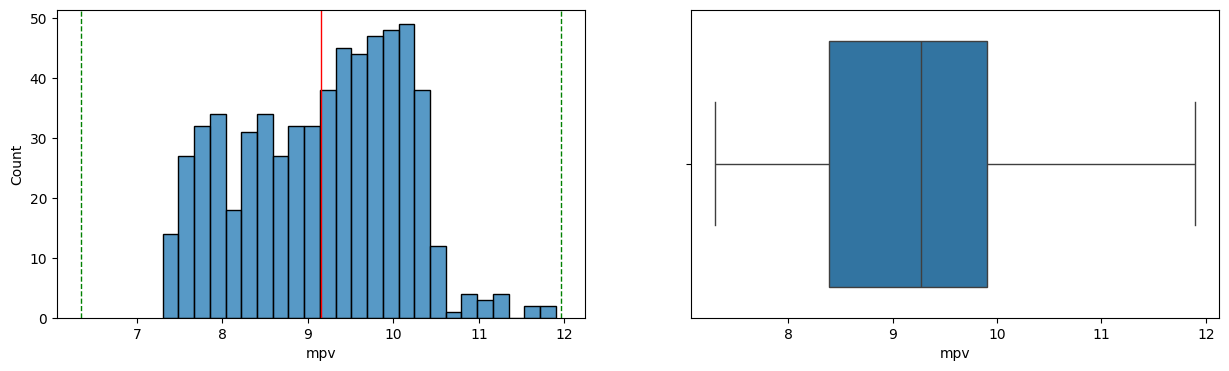

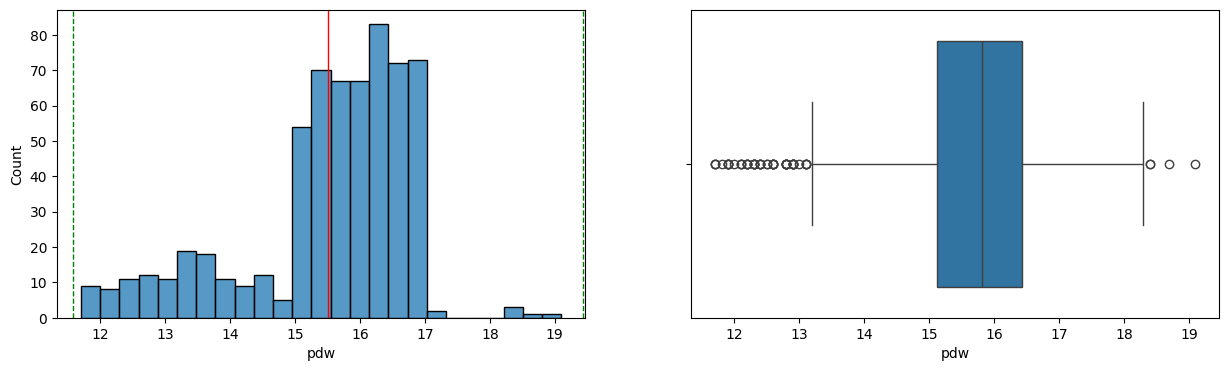

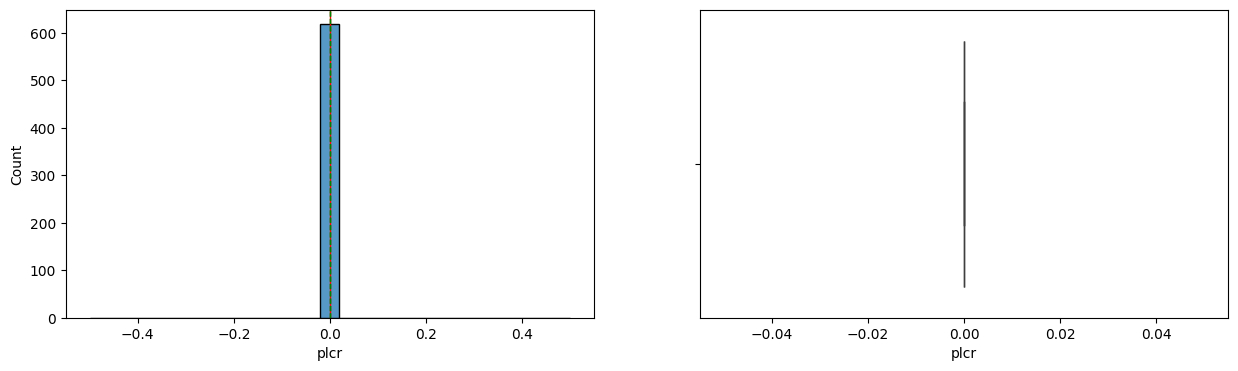

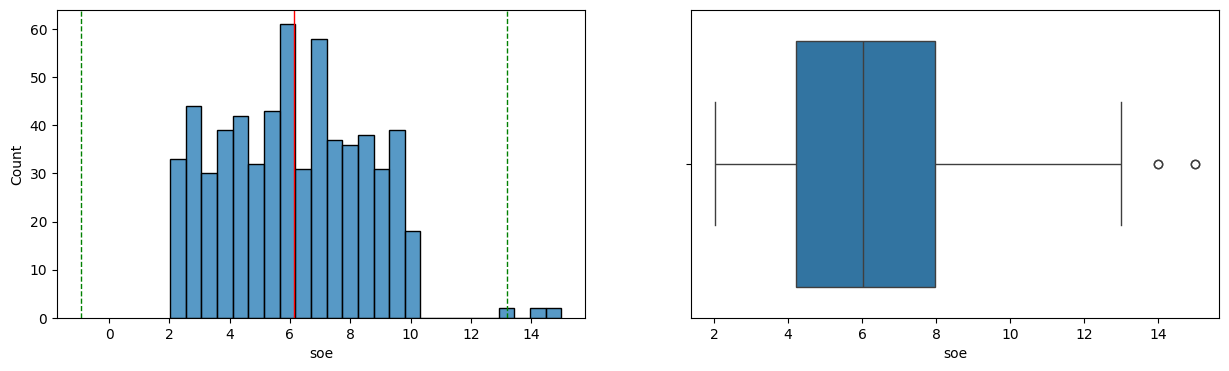

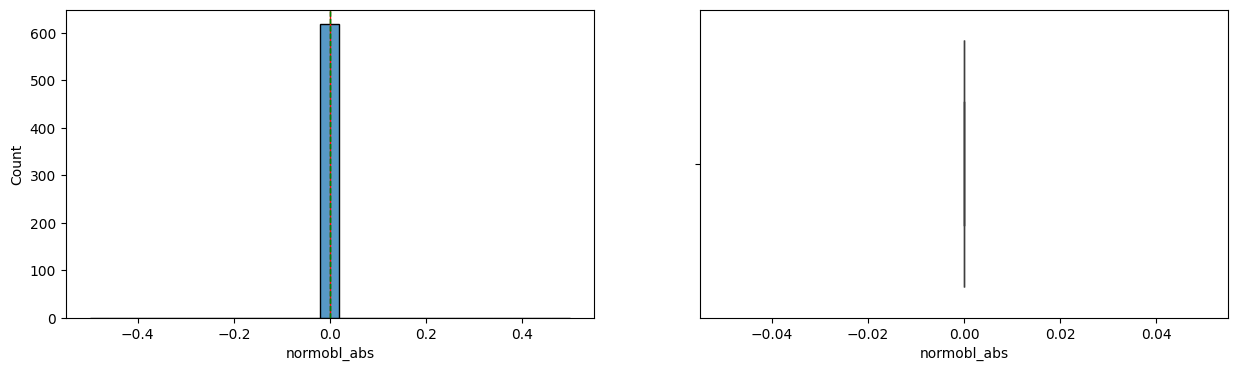

In [471]:
for el in num_list:
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 4))
    histplot = sns.histplot(data=data, x=el, ax=axes[0], bins=25)
    histplot.axvline(data[el].mean(), color='r', lw=1)
    histplot.axvline(data[el].mean()+ 3 * data[el].std(), color='g', ls='--', lw=1)
    histplot.axvline(data[el].mean()- 3 * data[el].std(), color='g', ls='--', lw=1)
    boxplot = sns.boxplot(data=data, x=el, ax=axes[1]);

In [472]:
# # Создаем тепловую карту пропусков
# plt.figure(figsize=(10, 6))
# sns.heatmap(data.isnull(), cbar=False, cmap='viridis', yticklabels=False)
# plt.title('Тепловая карта пропущенных значений', fontsize=16)
# plt.show()

In [473]:
# corr_matrix_df = round(data.corr(), 3)

# fig, ax = plt.subplots(figsize=(65, 60))
# sns.heatmap(
#     corr_matrix_df,
#     annot=True,
#     cmap='RdYlGn',
#     annot_kws={"fontsize": 18},
#     xticklabels=corr_matrix_df.columns,
#     yticklabels=corr_matrix_df.index,
#     linewidths=.5
# )
# ax.tick_params(axis="x", labelrotation=45, labelsize=14)
# ax.tick_params(axis="y", labelsize=14)
# plt.tight_layout()
# plt.show()

In [474]:
corr_matrix_df = round(data.corr(), 3)

#выведем пары с корреляцией выше 0.5
threshold = 0.5

high_correlations = (
    corr_matrix_df
    .stack()
    .reset_index()
    .rename(columns={0:'Корреляция'})
    .query('level_0 != level_1')
    .query(f'abs(Корреляция) >= {threshold}')
)

result = high_correlations.sort_values(by='Корреляция', ascending=False)[['level_0', 'level_1', 'Корреляция']]
display(result)

,level_0,level_1,Корреляция
882,plasma,blasty,1.000
1113,blasty,plasma,1.000
106,hgb,hct,0.711
139,hct,hgb,0.711
71,rbc,hgb,0.698
104,hgb,rbc,0.698
389,anisocytos,poikilocytos,0.636
521,poikilocytos,anisocytos,0.636
72,rbc,hct,0.595
138,hct,rbc,0.595


In [475]:
data.drop(columns=['hct', 'rbc', 'plasma', 'yunye', 'poikilocytos'], inplace=True)

In [476]:
corr_matrix_df = round(data.corr(), 3)

#выведем пары с корреляцией выше 0.5
threshold = 0.5

high_correlations = (
    corr_matrix_df
    .stack()
    .reset_index()
    .rename(columns={0:'Корреляция'})
    .query('level_0 != level_1')
    .query(f'abs(Корреляция) >= {threshold}')
)

result = high_correlations.sort_values(by='Корреляция', ascending=False)[['level_0', 'level_1', 'Корреляция']]
display(result)

,level_0,level_1,Корреляция


In [477]:
print('Проверка тренировочной выборки:'+'\n'+'-' * 30)
check_data_quality(data)

Проверка тренировочной выборки:
------------------------------
Количество дублей: 0

Количество признаков с пустыми значениями: 0

ret_abs: 100.00% уникальных значений
cp: 95.79% уникальных значений
hypochromia: 98.71% одинаковых значений
macrocytos: 98.38% одинаковых значений
microcytos: 97.73% одинаковых значений
mo_abs: 97.90% уникальных значений
eo_abs: 97.90% уникальных значений
ba_abs: 97.41% уникальных значений
pal: 95.95% уникальных значений
seg: 98.71% уникальных значений
plcr: 100.00% одинаковых значений
soe: 95.95% уникальных значений
myelo: 99.35% одинаковых значений
blasty: 99.84% одинаковых значений
normoblast: 99.51% одинаковых значений
normobl_abs: 100.00% одинаковых значений
prolym: 100.00% одинаковых значений
promyelo: 100.00% одинаковых значений


In [478]:
# # anemia_clomns = ['gender', 'age', 'rbc', 'hgb',	'hct', 'mcv', 'mchc', 'rdw', 'rdv_sd', 'cp', 'anisocytos', 'soe']
# anemia_clomns = ['gender', 'age', 'rbc', 'hgb',	'hct', 'mcv', 'mchc', 'rdw', 'rdv_sd', 'cp', 'anisocytos', 'soe']
anemia_clomns = ['hgb', 'mcv', 'mchc', 'rdw', 'rdv_sd', 'cp',]
data = data[anemia_clomns]

In [479]:
X_train = data.copy()
# Масштабирование
scaler = StandardScaler()
# scaler = RobustScaler()
data_scaled = scaler.fit_transform(data)

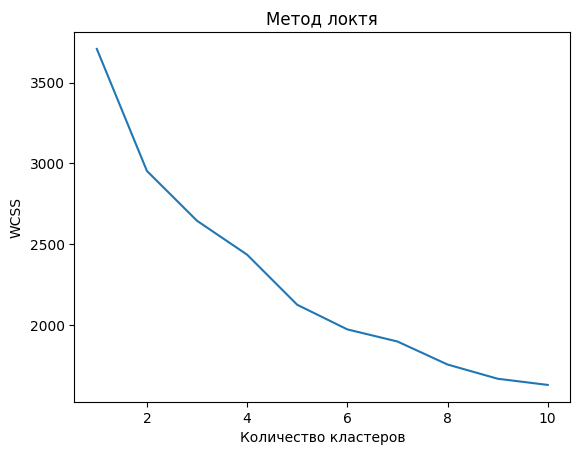

In [480]:
# Определение оптимального числа кластеров (метод локтя)
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(data_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss)
plt.title('Метод локтя')
plt.xlabel('Количество кластеров')
plt.ylabel('WCSS')
plt.show()

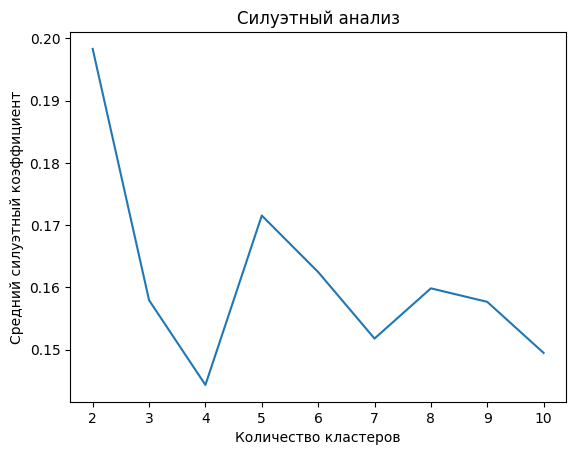

In [481]:
# Силуэтный анализ
silhouette_scores = []
for i in range(2, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    cluster_labels = kmeans.fit_predict(data_scaled)
    silhouette_avg = silhouette_score(data_scaled, cluster_labels)
    silhouette_scores.append(silhouette_avg)

plt.plot(range(2, 11), silhouette_scores)
plt.title('Силуэтный анализ')
plt.xlabel('Количество кластеров')
plt.ylabel('Средний силуэтный коэффициент')
plt.show()

In [482]:
# Кластеризация K-means с оптимальным числом кластеров
optimal_clusters = 5  # Пример, замените на выбранное значение
kmeans = KMeans(n_clusters=optimal_clusters, random_state=42)
clusters = kmeans.fit_predict(data_scaled)

In [457]:
from sklearn.mixture import GaussianMixture

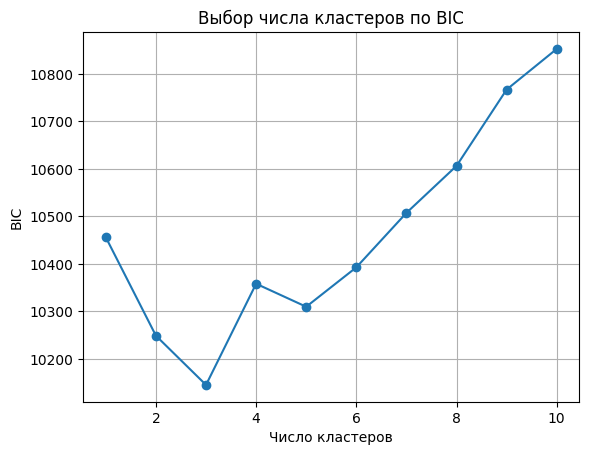

In [458]:
bic_scores = []
n_components_range = range(1, 11)

for n in n_components_range:
    gmm = GaussianMixture(n_components=n, covariance_type='full', random_state=42)
    gmm.fit(data_scaled)
    bic_scores.append(gmm.bic(data_scaled))

plt.plot(n_components_range, bic_scores, marker='o')
plt.xlabel('Число кластеров')
plt.ylabel('BIC')
plt.title('Выбор числа кластеров по BIC')
plt.grid()
plt.show()

In [459]:
# Выбор числа кластеров (можно подобрать через BIC/AIC или силуэтный анализ)
n_clusters = 3

# Создание и обучение модели
gmm = GaussianMixture(
    n_components=n_clusters,
    covariance_type='full',  # полная ковариационная матрица
    random_state=42
)
gmm.fit(data_scaled)  # обучение на масштабированных данных

# Предсказание кластеров
clusters = gmm.predict(data_scaled)

/var/folders/qk/1wwv7nb11h91kq3j74pdwfz00000gn/T/ipykernel_16527/1048864204.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Cluster'] = clusters


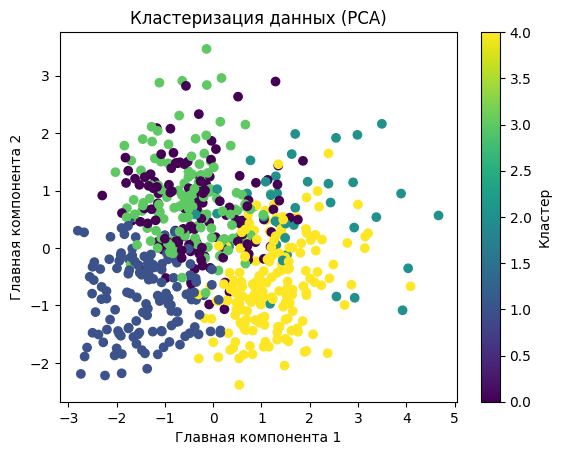

                hgb        mcv        mchc        rdw     rdv_sd        cp
Cluster                                                                   
0        107.884061  84.665783  341.027450  12.859382  52.710623  0.962696
1         99.621025  78.940823  361.679216  12.999534  43.199780  0.935312
2        117.605263  88.378947  328.368421  17.334211  46.490041  0.912867
3         90.073950  82.584489  344.048235  13.141063  51.256552  0.883489
4        130.544966  92.276935  336.502812  13.043357  44.360809  0.907669


In [483]:
# Добавление меток кластеров в исходные данные
data['Cluster'] = clusters

# Визуализация с PCA
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
principal_components = pca.fit_transform(data_scaled)
plt.scatter(principal_components[:, 0], principal_components[:, 1], c=clusters, cmap='viridis')
plt.title('Кластеризация данных (PCA)')
plt.xlabel('Главная компонента 1')
plt.ylabel('Главная компонента 2')
plt.colorbar(label='Кластер')
plt.show()

# Анализ кластеров
cluster_means = data.groupby('Cluster').mean()
print(cluster_means)

In [286]:
from sklearn.preprocessing import normalize
from keras.layers import Input, Dense
from keras.models import Model
from keras.optimizers import SGD

# Масштабирование

X_train = data.copy()

scaler = StandardScaler()
# scaler = RobustScaler()
data_scaled = scaler.fit_transform(X_train)

# Предобучение автоэнкодера
input_dim = X_train.shape[1]
encoding_dim = X_train.shape[1]
input_layer = Input(shape=(input_dim,))
encoder = Dense(encoding_dim, activation='relu')(input_layer)
autoencoder = Model(inputs=input_layer, outputs=encoder)
autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.fit(X_train, X_train, epochs=50)

# Извлекаем признаки
encoded_data = autoencoder.predict(X_train)



Epoch 1/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 11700.0664
Epoch 2/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 10269.3613
Epoch 3/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 9245.9258
Epoch 4/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 8359.6748
Epoch 5/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 7782.9629
Epoch 6/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 7442.1201
Epoch 7/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 7090.9263
Epoch 8/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6644.9409
Epoch 9/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6487.2734
Epoch 10/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 6358.1235 
Epoch 11/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6315.3179
Epoch 12/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6018.9673
Epoch 13/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6216.5635
Epoch 14/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 5923.3560
Epoch 15/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 

In [287]:
# Кластеризация K-means для инициализации
kmeans = KMeans(n_clusters=4)
y_pred = kmeans.fit_predict(encoded_data)

# DEC (дообучение с кластеризационным loss)
# (здесь нужна дополнительная реализация KL-дивергенции)

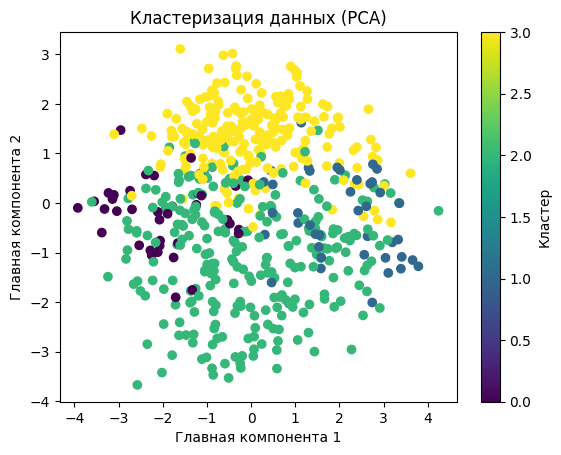

           gender        age         hgb        mcv        mchc        rdw  \
Cluster                                                                      
0        0.505435  73.467391  118.700001  88.566415  340.936954  13.230596   
1        0.578947  71.131579   94.371783  81.916402  351.540685  13.363377   
2        0.076923  75.192308  117.692308  83.461538  333.230769  13.672028   
3        0.393701  76.228346  112.718562  84.135713  341.862872  13.205310   

            rdv_sd        cp  anisocytos       wbc  ...        seg   mxd_abs  \
Cluster                                             ...                        
0        47.189555  0.922127         0.0  6.757117  ...  58.966737  0.534417   
1        48.452542  0.920249         0.0  4.289874  ...  59.378258  0.459802   
2        47.437322  0.918006         0.0  8.718679  ...  59.384012  0.592991   
3        48.570708  0.919168         0.0  8.289381  ...  59.287403  0.577162   

                plt       mpv        pdw       soe

In [288]:
# Добавление меток кластеров в исходные данные
data['Cluster'] = y_pred

# Визуализация с PCA
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
principal_components = pca.fit_transform(data_scaled)
plt.scatter(principal_components[:, 0], principal_components[:, 1], c=clusters, cmap='viridis')
plt.title('Кластеризация данных (PCA)')
plt.xlabel('Главная компонента 1')
plt.ylabel('Главная компонента 2')
plt.colorbar(label='Кластер')
plt.show()

# Анализ кластеров
cluster_means = data.groupby('Cluster').mean()
print(cluster_means)